In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.pyplot as plt

# Screen Time Balance with Fuzzy Cognitive Maps (FCM) with scenario / intervention approach

I chose the project's topic Screen Time Balance and Digital Habit Recommendation system. 
Questions we may ask ourselves would be: 

- What happens if late-night phone use becomes too high?
- What happens if phone glances are reduced?
- Which intervention improves digital habits the most?

## Project idea

We model a fuzzy-logic digital habit recommendation system with the following input habits:

1. **ScreenGlances**: how often a user checks the phone 
2. **IdleChecking**: checking the phone during idle moments without a clear purpose (under 30s) e.g. waiting somehwere and quickly checking phobe because bored.
3. **LateNightUse**: screen use late in the evening or at night e.g. after 9pm.
4. **SocialMediaUsage**: total screen time spent on social media

These inputs affect higher-level outcomes like:

**FocusQuality**: ability to concentrate during study or work  
**SleepQuality**: quality of sleep  
**StressLevel**: perceived digital overload or mental pressure  
**HabitBalance**: overall balance of digital habits  
**RecommendationNeed**: how strongly the system should recommend behaviour changes

The goal is to see how changes in habits propagate through the system and to generate helpful recommendations.

In [3]:
concepts = [
    "ScreenGlances",
    "IdleChecking",
    "LateNightUse",
    "SocialMediaUsage",
    "FocusQuality",
    "SleepQuality",
    "StressLevel",
    "HabitBalance",
    "RecommendationNeed",
]

concepts

['ScreenGlances',
 'IdleChecking',
 'LateNightUse',
 'SocialMediaUsage',
 'FocusQuality',
 'SleepQuality',
 'StressLevel',
 'HabitBalance',
 'RecommendationNeed']

### Fuzzy Cognitive Map

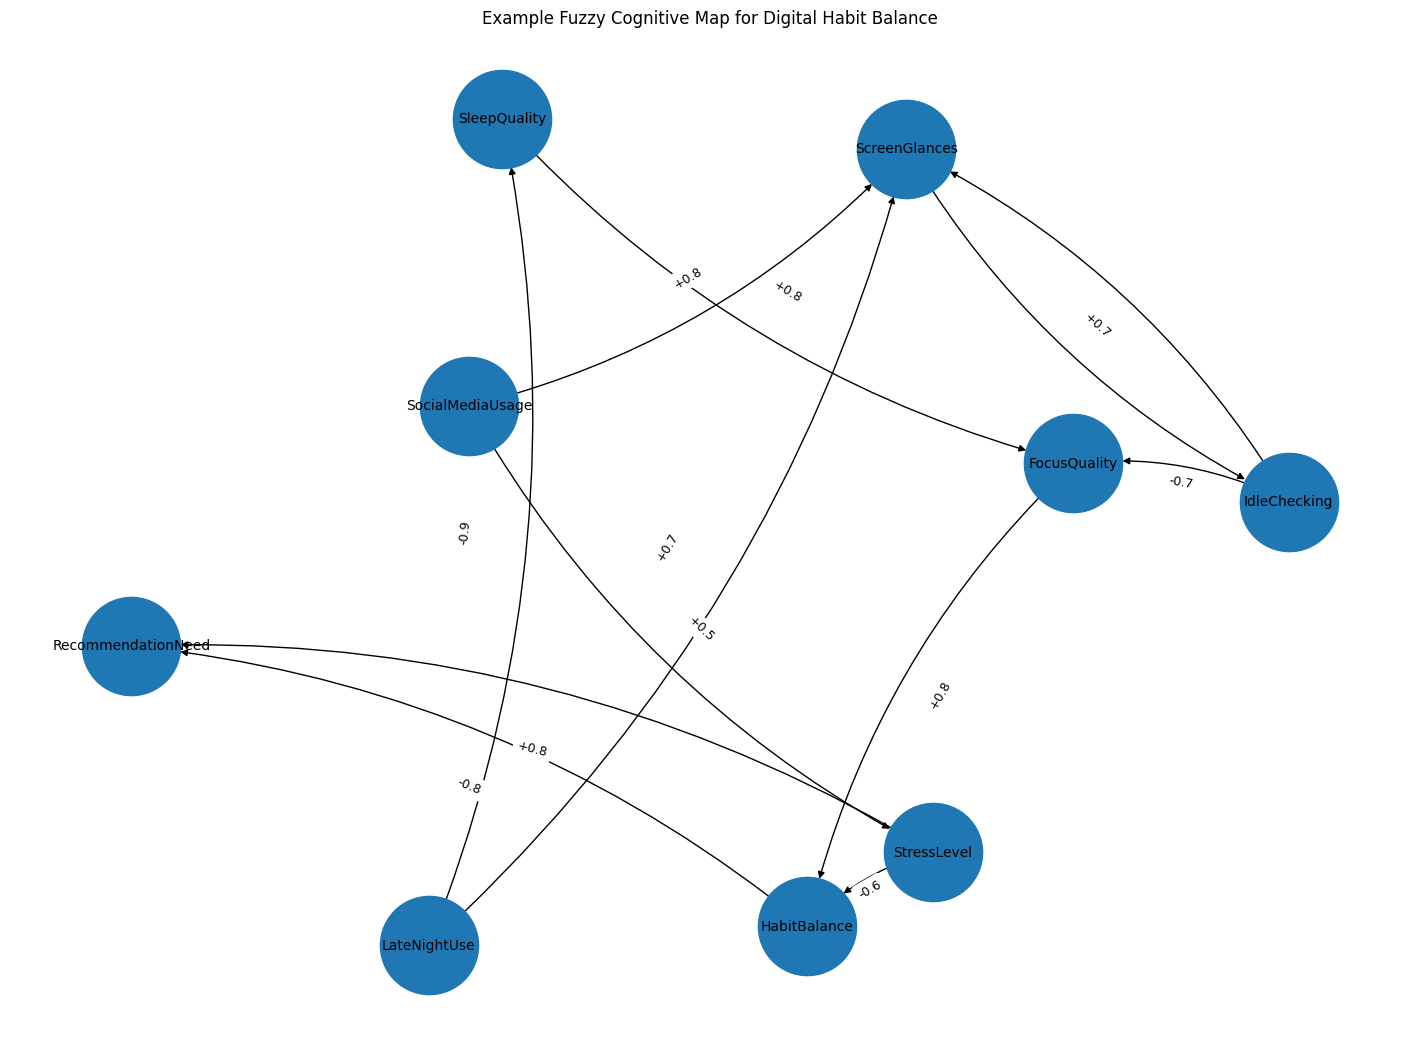

In [4]:
# Directed graph with weights
G = nx.DiGraph()

nodes = [
    'ScreenGlances',
    'IdleChecking',
    'LateNightUse',
    'SocialMediaUsage',
    'FocusQuality',
    'SleepQuality',
    'StressLevel',
    'HabitBalance',
    'RecommendationNeed'
]
G.add_nodes_from(nodes)

# How does one affect the other
edges = [
    ('ScreenGlances', 'IdleChecking', 0.7),
    ('IdleChecking', 'ScreenGlances', 0.7),
    ('SocialMediaUsage', 'ScreenGlances', 0.4),
    ('IdleChecking', 'ScreenGlances', 0.7),
    ('SocialMediaUsage', 'ScreenGlances', 0.8),
    ('LateNightUse', 'ScreenGlances', 0.7),
    ('IdleChecking', 'FocusQuality', -0.7),
    ('LateNightUse', 'SleepQuality', -0.9),
    ('SocialMediaUsage', 'StressLevel', 0.5),
    ('SleepQuality', 'FocusQuality', 0.8),
    ('FocusQuality', 'HabitBalance', 0.8),
    ('StressLevel', 'HabitBalance', -0.6),
    ('StressLevel', 'RecommendationNeed', 0.8),
    ('HabitBalance', 'RecommendationNeed', -0.8),
]

for source, target, weight in edges:
    G.add_edge(source, target, weight=weight)

pos = nx.spring_layout(G,  seed=42, k=1.5)

plt.figure(figsize=(14, 10))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=5000,
    font_size=10,
    arrows=True,
    connectionstyle="arc3,rad=0.15"
)

edge_labels = {(u, v): f"{d['weight']:+.1f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("Example Fuzzy Cognitive Map for Digital Habit Balance")
plt.show()

## Create the weight matrix out of fuzzy cognitive map

The weight matrix stores how strongly one concept influences another.

- positive weight: increase in one concept tends to increase the other
- negative weight: increase in one concept tends to decrease the other

These weights are purely based on my intuition.
Some examples: 
- More ScreenGlance usually increases IdleChecking
- More LateNightUse often reduces SleepQuality

In [5]:
W = pd.DataFrame(0.0, index=concepts, columns=concepts)

# Neural network: behaviour -> internal state -> recommendation

# -----------------------------
# Behaviour -> behaviour
# -----------------------------
W.loc["ScreenGlances", "IdleChecking"] = 0.7
W.loc["IdleChecking", "ScreenGlances"] = 0.5
W.loc["SocialMediaUsage", "ScreenGlances"] = 0.6
W.loc["LateNightUse", "ScreenGlances"] = 0.4

# -----------------------------
# Behaviour -> internal state
# -----------------------------
W.loc["IdleChecking", "FocusQuality"] = -0.7
W.loc["ScreenGlances", "FocusQuality"] = -0.5
W.loc["LateNightUse", "SleepQuality"] = -0.9
W.loc["LateNightUse", "StressLevel"] = 0.5
W.loc["SocialMediaUsage", "StressLevel"] = 0.6
W.loc["SocialMediaUsage", "FocusQuality"] = -0.6

# -----------------------------
# Internal state -> internal state
# -----------------------------
W.loc["SleepQuality", "FocusQuality"] = 0.8
W.loc["FocusQuality", "StressLevel"] = -0.6
W.loc["StressLevel", "FocusQuality"] = -0.5
W.loc["FocusQuality", "HabitBalance"] = 0.8
W.loc["SleepQuality", "HabitBalance"] = 0.7
W.loc["StressLevel", "HabitBalance"] = -0.7

# -----------------------------
# Behaviour -> habit balance
# -----------------------------
W.loc["IdleChecking", "HabitBalance"] = -0.5
W.loc["LateNightUse", "HabitBalance"] = -0.6
W.loc["SocialMediaUsage", "HabitBalance"] = -0.6

# -----------------------------
# Behaviour -> recommendation need
# -----------------------------
W.loc["StressLevel", "RecommendationNeed"] = 0.8
W.loc["HabitBalance", "RecommendationNeed"] = -0.8
W.loc["LateNightUse", "RecommendationNeed"] = 0.5
W.loc["IdleChecking", "RecommendationNeed"] = 0.5
W.loc["SocialMediaUsage", "RecommendationNeed"] = 0.4

W

,ScreenGlances,IdleChecking,LateNightUse,SocialMediaUsage,FocusQuality,SleepQuality,StressLevel,HabitBalance,RecommendationNeed
ScreenGlances,0.0,0.7,0.0,0.0,-0.5,0.0,0.0,0.0,0.0
IdleChecking,0.5,0.0,0.0,0.0,-0.7,0.0,0.0,-0.5,0.5
LateNightUse,0.4,0.0,0.0,0.0,0.0,-0.9,0.5,-0.6,0.5
SocialMediaUsage,0.6,0.0,0.0,0.0,-0.6,0.0,0.6,-0.6,0.4
FocusQuality,0.0,0.0,0.0,0.0,0.0,0.0,-0.6,0.8,0.0
SleepQuality,0.0,0.0,0.0,0.0,0.8,0.0,0.0,0.7,0.0
StressLevel,0.0,0.0,0.0,0.0,-0.5,0.0,0.0,-0.7,0.8
HabitBalance,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.8
RecommendationNeed,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## FCM simulator

In [6]:
from fcmpy import FcmSimulator

# Initial state vector with random values
init_state = {
    "ScreenGlances": 0.8,
    "IdleChecking": 0.7,
    "LateNightUse": 0.6,
    "SocialMediaUsage": 0.7,
    "FocusQuality": 0.4,
    "SleepQuality": 0.5,
    "StressLevel": 0.6,
    "HabitBalance": 0.3,
    "RecommendationNeed": 0.2
}

# Run simulator
sim = FcmSimulator()

results = sim.simulate(
    initial_state=init_state,
    weight_matrix=W,
    transfer="sigmoid",
    inference="mKosko",
    thresh=0.001,
    iterations=50,
    l=1
)

results

ModuleNotFoundError: No module named 'fcmpy'

In [ ]:
plt.figure(figsize=(14, 8))
results.plot(figsize=(14, 8))
plt.xlabel("Simulation step")
plt.ylabel("Concept activation")
plt.title("FCM Simulation: Digital Habit Balance")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
final_state = results.iloc[-1]
final_state.sort_values(ascending=False)

## Scenarios

We have three user profiles:

#### Scenario A: Balanced student
- medium phone glances
- low idle checking
- low late-night use
- low social media use

#### Scenario B: Distracted student
- high glances
- high idle checking
- medium late-night use
- low social media use

#### Scenario C: Night scroller
- medium glances
- medium idle checking
- very high late-night use
- low social media use

In [ ]:
scenario_balanced = {
    "ScreenGlances": 0.30,
    "IdleChecking": 0.15,
    "LateNightUse": 0.20,
    "SocialMediaUsage": 0.10,
    "FocusQuality": 0.70,
    "SleepQuality": 0.80,
    "StressLevel": 0.30,
    "HabitBalance": 0.65,
    "RecommendationNeed": 0.20,
}

scenario_distracted = {
    "ScreenGlances": 0.85,
    "IdleChecking": 0.80,
    "LateNightUse": 0.55,
    "SocialMediaUsage": 0.30,
    "FocusQuality": 0.35,
    "SleepQuality": 0.45,
    "StressLevel": 0.60,
    "HabitBalance": 0.30,
    "RecommendationNeed": 0.60,
}

scenario_night_scroller = {
    "ScreenGlances": 0.55,
    "IdleChecking": 0.50,
    "LateNightUse": 0.95,
    "SocialMediaUsage": 0.25,
    "FocusQuality": 0.40,
    "SleepQuality": 0.30,
    "StressLevel": 0.65,
    "HabitBalance": 0.25,
    "RecommendationNeed": 0.70,
}

In [ ]:
res_balanced = sim.simulate(initial_state=scenario_balanced,
    weight_matrix=W,
    transfer="sigmoid",
    inference="mKosko",
    thresh=0.001,
    iterations=15,
    l=1.2)
res_distracted = sim.simulate( initial_state=scenario_distracted,
    weight_matrix=W,
    transfer="sigmoid",
    inference="mKosko",
    thresh=0.001,
    iterations=15,
    l=1.2)
res_night = sim.simulate( initial_state=scenario_night_scroller,
    weight_matrix=W,
    transfer="sigmoid",
    inference="mKosko",
    thresh=0.001,
    iterations=15,
    l=1.2)

final_states = pd.DataFrame({
    "BalancedStudent": res_balanced.iloc[-1],
    "DistractedStudent": res_distracted.iloc[-1],
    "NightScroller": res_night.iloc[-1],
}).round(3)

final_states

In [ ]:
scenarios_to_plot = {
    "Scenario A: Balanced student": res_balanced,
    "Scenario B: Distracted student": res_distracted,
    "Scenario C: Night scroller": res_night,
}

cols = ["FocusQuality", "SleepQuality", "StressLevel", "HabitBalance", "RecommendationNeed"]

for title, df in scenarios_to_plot.items():
    df[cols].plot(figsize=(10, 6), title=title)
    plt.xlabel("Iteration")
    plt.ylabel("Activation level")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()

In [ ]:
summary = final_states.loc[
    ["FocusQuality", "SleepQuality", "StressLevel", "HabitBalance", "RecommendationNeed"]
].T.sort_values("RecommendationNeed", ascending=False)

summary

#### Interpretation

- The Balanced student shows healthiest pattern -> Best habitBalance, least recommendation need
- The Distracted student shows weaker focus quiality and a stronger recommendation need.
- The Night scroller has worst values overall and highest REcommendation Need.

## Interventions

#### Intervention 1: Disable notifications
This should reduce:
- ScreenGlances
- IdleChecking

#### Intervention 2: Solitude deprivation walks (Newport)
This should reduce:
- ScreenGlances
- IdleChecking
- StressLevel
- HabitBalance

and improve:
- FocusQuality
- SleepQuality

#### Intervention 3: No phone use after 10pm
This should reduce:
- LateNightUse

and improve:
- SleepQuality

In [ ]:
def apply_intervention(state, intervention):
    new_state = dict(state)
    for concept, delta in intervention.items():
        new_state[concept] = float(np.clip(new_state[concept] + delta, 0, 1))
    return new_state

disable_notifications = {
    "ScreenGlances": -0.5,
    "IdleChecking": -0.20,
}

newport_walks = {
    "ScreenGlances": -0.20,
    "IdleChecking": -0.25,
    "StressLevel": -0.10,
    "HabitBalance": -0.03,
    "SleepQuality": 0.05,
    "FocusQuality": 0.10,
}

bedtime_mode = {
    "LateNightUse": -0.40,
    "SleepQuality": 0.15,
}

In [ ]:
# Example of intervention on a scenario
nightscroller_disable = apply_intervention(scenario_night_scroller, disable_notifications)
nightscroller_newport_walk = apply_intervention(scenario_night_scroller, newport_walks)
nightscroller_bedtime = apply_intervention(scenario_night_scroller, bedtime_mode)

res_disable = sim.simulate(
    initial_state=distracted_disable,
    weight_matrix=W,
    transfer="sigmoid",
    inference="mKosko",
    thresh=0.001,
    iterations=15,
    l=1.2
)

res_newport = sim.simulate(
    initial_state=distracted_phone_away,
    weight_matrix=W,
    transfer="sigmoid",
    inference="mKosko",
    thresh=0.001,
    iterations=15,
    l=1.2
)

res_bedtime = sim.simulate(
    initial_state=distracted_bedtime,
    weight_matrix=W,
    transfer="sigmoid",
    inference="mKosko",
    thresh=0.001,
    iterations=15,
    l=1.2
)

intervention_comparison = pd.DataFrame({
    "Baseline": res_night.iloc[-1],
    "DisableNotifications": res_disable.iloc[-1],
    "SolitudeWalks": res_newport.iloc[-1],
    "BedtimeMode": res_bedtime.iloc[-1],
}).loc[["FocusQuality", "SleepQuality", "StressLevel", "HabitBalance", "RecommendationNeed"]].round(3)

intervention_comparison

In [ ]:
ax = intervention_comparison.T.plot(kind="bar", figsize=(10, 5))
ax.set_title("Nightscroller: baseline vs interventions")
ax.set_ylabel("Final activation level")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### Interpretation
- The Notification Disabling helps the sleep quality a bit, but doesn't reduce Stress level by much.
- Same for Newport walks
- BedtimeMode has the most positive effect


## (Later for project) Generate recommendation text

Translate the final concept values into behaviour-based recommendations.

In [ ]:
def generate_recommendations(final_state):
    recommendations = []

    if final_state["LateNightUse"] > 0.70 or final_state["SleepQuality"] < 0.45:
        recommendations.append("Use bedtime mode after 22:00 and avoid scrolling before sleep.")

    if final_state["IdleChecking"] > 0.65 or final_state["ScreenGlances"] > 0.70:
        recommendations.append("Reduce idle checking by placing the phone out of reach during short breaks.")

    if final_state["FocusQuality"] < 0.50:
        recommendations.append("Keep the phone away during study sessions to protect focus.")

    if final_state["StressLevel"] > 0.65:
        recommendations.append("Disable non-essential notifications to reduce digital overload.")

    if final_state["SocialMediaUsage"] < 0.40:
        recommendations.append("Plan specific times for intentional digital use instead of checking by default.")

    ### and many more... (can we use some existing database for it?)

    if not recommendations:
        recommendations.append("Current digital habits look balanced. Keep using your devices intentionally.")

    return recommendations

## Printing the recommendations for the Nightscroller
print("\nNightscroller")
for rec in generate_recommendations(res_night.iloc[-1]):
    print("-", rec)

## Conclusion

For this project, the FCM Scenario / Intervention approach is much more suitable than the Class Importance approach, because the main research question for our project is:

**How do different digital habits influence focus, sleep, stress, and the need for recommendations, and what interventions improve the balance?**
This is exactly what an FCM does. 

## Next steps for project (to be discussed with group members)
- collect real user data or simulate more realistically
- correctly map raw measurements to fuzzy levels (low / medium / high)
- add more realistic recommendations